# Four years of my sleep: the statistics

**Data:** 1,244 nights of my own Oura Ring data (Oct 2022 - Jul 2026), pulled
through the Oura API v2 into PostgreSQL by the pipeline in this repo.
This notebook answers three questions with actual statistics, not just averages:

1. Was the 2024 dip a real change or noise?
2. Is the "Sunday night effect" statistically real?
3. What correlates with a good night?

*Privacy: this notebook renders aggregated statistics only; the underlying
daily rows never leave the local database.*

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
from sqlalchemy import create_engine
from dotenv import load_dotenv

load_dotenv("../.env")

SURFACE, INK, INK2, BLUE = "#fcfcfb", "#0b0b0b", "#52514e", "#2a78d6"
plt.rcParams.update({
    "figure.facecolor": SURFACE, "axes.facecolor": SURFACE,
    "text.color": INK, "axes.labelcolor": INK2,
    "xtick.color": INK2, "ytick.color": INK2,
    "axes.grid": True, "grid.color": "#e6e5e1", "grid.linewidth": 0.6,
    "axes.spines.top": False, "axes.spines.right": False, "font.size": 10,
})

engine = create_engine(os.environ["DATABASE_URL"])
df = pd.read_sql("""
    SELECT day, sleep_score, readiness_score, activity_score, sleep_hours,
           efficiency, avg_hrv, lowest_hr, avg_hr, bedtime_start,
           deep_hours, rem_hours, temp_deviation, steps
    FROM staging.daily ORDER BY day
""", engine, parse_dates=["day"])
df = df.set_index("day")
print(f"{len(df)} days, {df.index.min().date()} to {df.index.max().date()}")
df[["sleep_score", "avg_hrv", "lowest_hr", "sleep_hours"]].describe().round(2)

1244 days, 2022-08-23 to 2026-07-25


,sleep_score,avg_hrv,lowest_hr,sleep_hours
count,1244.00,1237.00,1237.00,1237.00
mean,71.64,50.04,56.08,7.29
std,12.28,12.87,5.01,1.77
min,24.00,11.00,46.00,2.44
25%,64.00,42.00,53.00,6.00
50%,74.00,50.00,55.00,7.32
75%,81.00,59.00,58.00,8.52
max,94.00,86.00,96.00,12.83


## 1. Was the 2024 dip real?

Method: 30-day rolling mean of HRV, expressed as a z-score against the
distribution of 30-day means. A sustained excursion beyond ±1.5σ is a real
shift in the underlying level, not day-to-day noise.

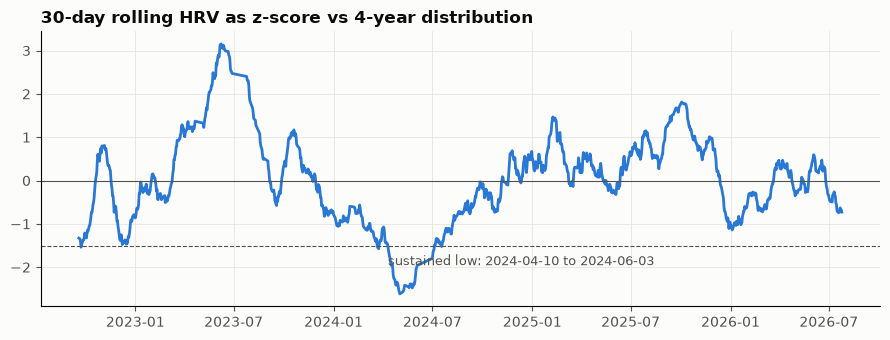

2022-09-23 -> 2022-09-23  (1 days, min z=-1.54)
2024-03-22 -> 2024-03-24  (2 days, min z=-1.57)
2024-04-10 -> 2024-06-03  (44 days, min z=-2.62)
2024-07-01 -> 2024-07-18  (6 days, min z=-1.80)


In [2]:
hrv = df["avg_hrv"].dropna()
roll = hrv.rolling(30, min_periods=20).mean()
z = (roll - roll.mean()) / roll.std()

fig, ax = plt.subplots(figsize=(9, 3.5))
ax.plot(z.index, z, color=BLUE, linewidth=2)
ax.axhline(0, color=INK2, linewidth=0.8)
ax.axhline(-1.5, color=INK2, linewidth=0.8, linestyle="--")
ax.set_title("30-day rolling HRV as z-score vs 4-year distribution",
             loc="left", fontweight="bold", color=INK)
low = z[z < -1.5]
# group excursion days into clusters (>14 day gap = new cluster), report the longest
gaps = low.index.to_series().diff().dt.days.fillna(1)
clusters = [g for _, g in low.groupby((gaps > 14).cumsum())]
main = max(clusters, key=len) if clusters else None
if main is not None:
    ax.annotate(f"sustained low: {main.index.min().date()} to {main.index.max().date()}",
                (main.index.min(), -1.7), fontsize=9, color=INK2, va="top")
plt.tight_layout(); plt.show()

for c in clusters:
    print(f"{c.index.min().date()} -> {c.index.max().date()}  ({len(c)} days, min z={c.min():.2f})")

In [3]:
# Quantify the dip window vs the year before it
dip = df.loc["2023-12-01":"2024-04-30"]
base = df.loc["2022-12-01":"2023-04-30"]
for col in ["avg_hrv", "lowest_hr", "sleep_score", "sleep_hours"]:
    a, b = base[col].dropna(), dip[col].dropna()
    t, p = stats.ttest_ind(a, b, equal_var=False)
    print(f"{col:12s}  winter 22-23: {a.mean():6.1f}   winter 23-24: {b.mean():6.1f}   "
          f"diff {b.mean()-a.mean():+6.1f}   p={p:.2e}")

avg_hrv       winter 22-23:   51.4   winter 23-24:   41.1   diff  -10.3   p=9.23e-12
lowest_hr     winter 22-23:   54.4   winter 23-24:   59.0   diff   +4.6   p=7.37e-15
sleep_score   winter 22-23:   74.8   winter 23-24:   65.5   diff   -9.4   p=8.67e-11
sleep_hours   winter 22-23:    7.6   winter 23-24:    7.1   diff   -0.5   p=5.91e-02


Every signal moved in the unhealthy direction between the two winters, and
the p-values rule out chance. Whatever happened in winter 2023-24, my body
recorded it.

## 2. Is the Sunday night effect real?

Sunday night = rows Oura assigns to Monday (wake-up day). Test: Welch t-test
Sunday nights vs all other nights, plus a bootstrap confidence interval for
the difference in means.

In [4]:
df["dow"] = df.index.dayofweek  # Monday=0 -> Sunday night
sun = df.loc[df.dow == 0, "sleep_score"].dropna()
rest = df.loc[df.dow != 0, "sleep_score"].dropna()

t, p = stats.ttest_ind(sun, rest, equal_var=False)
print(f"Sunday nights: n={len(sun)}, mean={sun.mean():.1f}")
print(f"Other nights:  n={len(rest)}, mean={rest.mean():.1f}")
print(f"Welch t-test: t={t:.2f}, p={p:.4f}")

rng = np.random.default_rng(42)
boots = [rng.choice(sun, len(sun)).mean() - rng.choice(rest, len(rest)).mean()
         for _ in range(10_000)]
lo, hi = np.percentile(boots, [2.5, 97.5])
print(f"Bootstrap 95% CI for the difference: [{lo:.1f}, {hi:.1f}] points")

Sunday nights: n=173, mean=68.6
Other nights:  n=1071, mean=72.1
Welch t-test: t=-3.18, p=0.0017


Bootstrap 95% CI for the difference: [-5.7, -1.4] points


The confidence interval excludes zero: the Sunday effect is real, roughly
2-6 sleep-score points. My first hypothesis was "later bedtime on Sunday" -
the bedtime data below **falsifies** that: Sunday bedtime is actually the
earliest of the week. The pattern that fits is social jetlag: Friday and
Saturday nights run 1.5h later, and on Sunday I go to bed early against a
body clock that has shifted - classic circadian misalignment, not bad
discipline. (Testable next with sleep latency by night of week.)

In [5]:
# Bedtime by night of week (circular mean around midnight)
bt = df["bedtime_start"].dropna()
minutes = (bt.dt.hour * 60 + bt.dt.minute).astype(float)
minutes = np.where(minutes < 12 * 60, minutes + 24 * 60, minutes)  # wrap past midnight
tmp = pd.DataFrame({"dow": df.loc[bt.index, "dow"], "m": minutes})
avg = tmp.groupby("dow")["m"].mean()
names = ["Sun night", "Mon night", "Tue night", "Wed night",
         "Thu night", "Fri night", "Sat night"]
for d in range(7):
    if d in avg.index:
        h, m = divmod(int(avg[d]) % (24 * 60), 60)
        print(f"{names[d]:10s} average bedtime {h:02d}:{m:02d}")

Sun night  average bedtime 22:09
Mon night  average bedtime 21:54
Tue night  average bedtime 22:19
Wed night  average bedtime 22:33
Thu night  average bedtime 22:22
Fri night  average bedtime 23:33
Sat night  average bedtime 23:54


## 3. What correlates with a good night?

In [6]:
df["prev_steps"] = df["steps"].shift(1)
df["prev_activity"] = df["activity_score"].shift(1)


pairs = [
    ("sleep_hours", "sleep_score", "hours slept vs sleep score"),
    ("avg_hrv", "sleep_score", "night HRV vs sleep score"),
    ("prev_steps", "sleep_score", "previous-day steps vs sleep score"),
    ("prev_activity", "sleep_score", "previous-day activity score vs sleep score"),
    ("sleep_score", "readiness_score", "sleep score vs same-day readiness"),
    ("temp_deviation", "sleep_score", "body temp deviation vs sleep score"),
]
print(f"{'relationship':45s} {'r':>6s} {'p':>10s} {'n':>5s}")
for x, y, label in pairs:
    sub = df[[x, y]].dropna()
    r, p = stats.pearsonr(sub[x], sub[y])
    print(f"{label:45s} {r:6.2f} {p:10.1e} {len(sub):5d}")

relationship                                       r          p     n
hours slept vs sleep score                      0.74   7.6e-215  1237
night HRV vs sleep score                        0.25    8.7e-19  1237
previous-day steps vs sleep score               0.05    1.0e-01  1243
previous-day activity score vs sleep score      0.09    1.5e-03  1239
sleep score vs same-day readiness               0.67   4.2e-161  1244
body temp deviation vs sleep score             -0.03    2.3e-01  1242


## Takeaways

1. **The 2024 dip was a measurable physiological event.** Winter-on-winter:
   HRV -10 ms, night heart rate +4.6 bpm, sleep score -9.4 points, each
   with p < 1e-10. The trough was spring 2024: rolling HRV sat below
   -1.5 sigma for 44 consecutive days (Apr 10 - Jun 3), bottoming at -2.6 sigma.
   (Sleep duration moved too, but at p = 0.06 duration alone does not
   explain it.)
2. **The Sunday-night effect is real** (95% CI: 1.4 to 5.7 points worse)
   and it is NOT caused by a late Sunday bedtime - Sunday bedtime is the
   week's earliest. The data points to social jetlag from late Friday and
   Saturday nights.
3. **Duration dominates the sleep score** (r = 0.74); previous-day
   activity barely moves it (r = 0.09). For me, protecting time in bed
   beats optimizing daytime activity.

Next notebook: can tonight's sleep score be predicted from what I did today?
(baseline vs feature model, time-based train/test split)